In [1]:
import pandas as pd

housing = pd.read_csv("/kaggle/input/datasets/zaferaydin/california-housing/housing.csv")

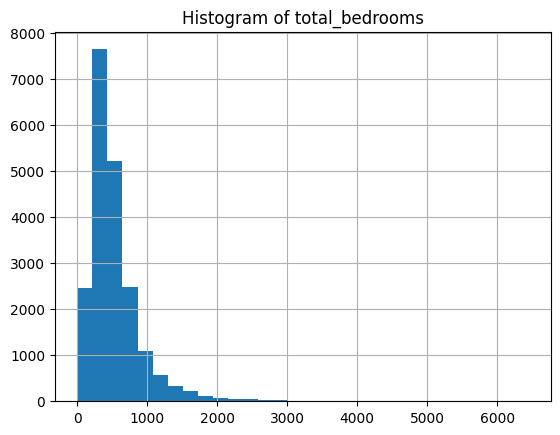

total_bedrooms skewness: 3.4595463315233435


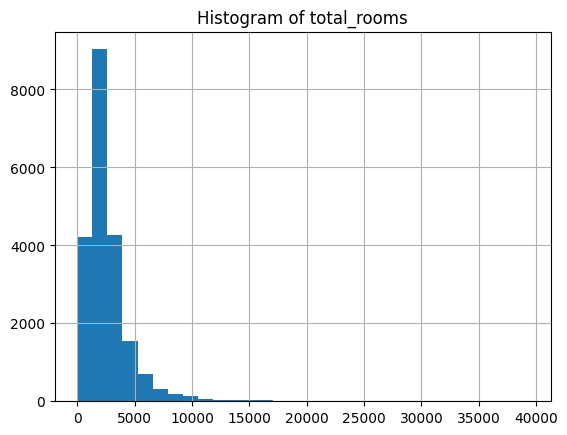

total_rooms skewness: 4.147343450632158


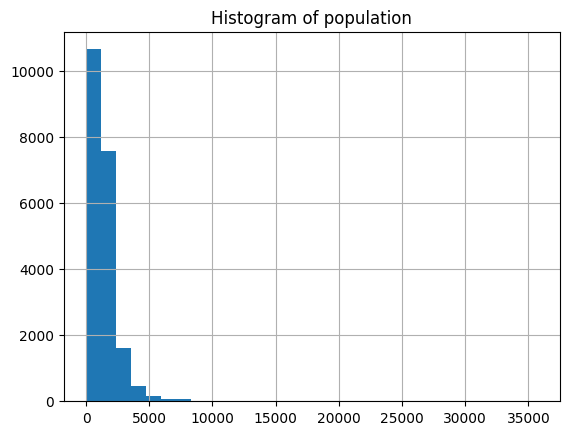

population skewness: 4.935858226727122


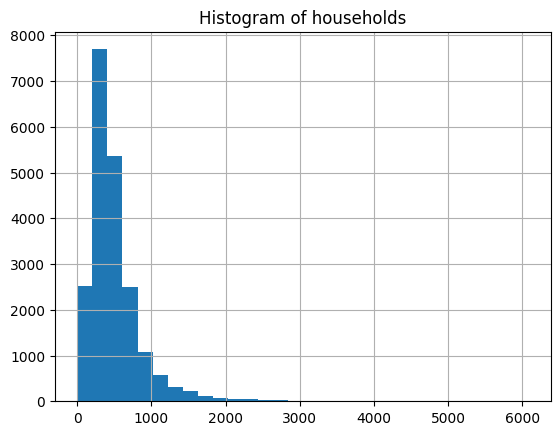

households skewness: 3.4104377116671456


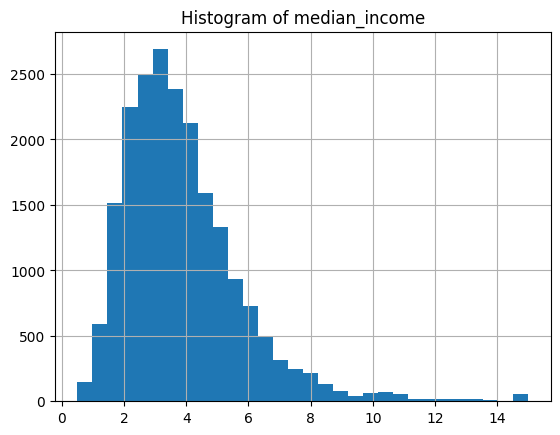

median_income skewness: 1.6466567021344465


In [2]:
#q1(a)
import matplotlib.pyplot as plt

features = ["total_bedrooms", "total_rooms", "population", "households", "median_income"]

for feature in features:
    plt.figure()
    housing[feature].hist(bins=30)
    plt.title(f"Histogram of {feature}")
    plt.show()
    
    print(f"{feature} skewness:", housing[feature].skew())

The histograms of the selected features (total_bedrooms, total_rooms, population, households, and median_income) were plotted using 30 bins. The distributions of most features are visibly right-skewed, with a long tail extending toward higher values.

The skewness values confirm this observation:

* total_bedrooms: 3.46
* total_rooms: 4.15
* population: 4.94
* households: 3.41
* median_income: 1.65

All features have positive skewness values, indicating that their distributions are skewed to the right. This suggests the presence of extreme high values (outliers) in the dataset.

Among these features, population and total_rooms show the highest skewness, meaning they are the most heavily skewed. Median_income has relatively lower skewness but is still not normally distributed.

In conclusion, all features exhibit skewed distributions, and transformation techniques (such as Box-Cox) may be necessary to make them more symmetric for machine learning models.

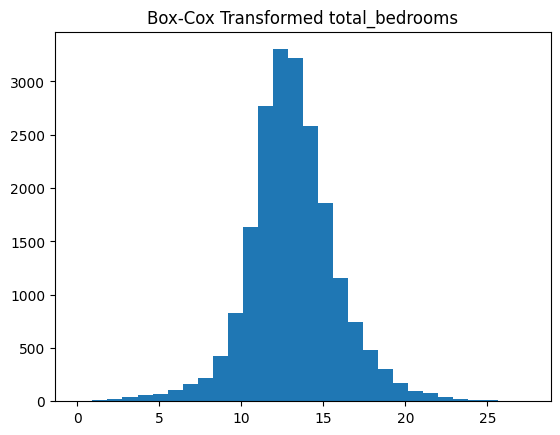

total_bedrooms skewness after transform: 0.11271363176228452


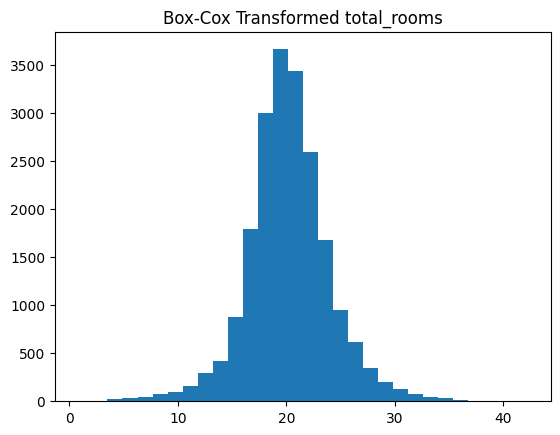

total_rooms skewness after transform: 0.12329368652880203


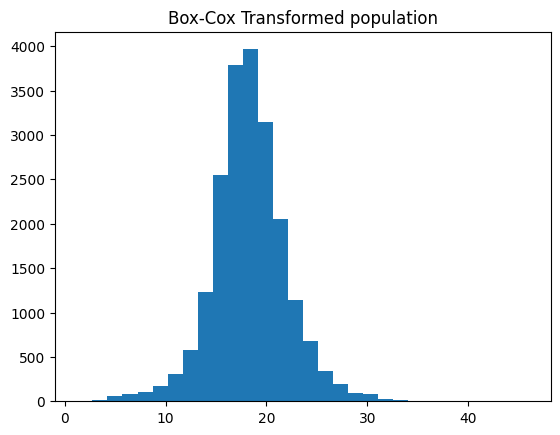

population skewness after transform: 0.11308103343215735


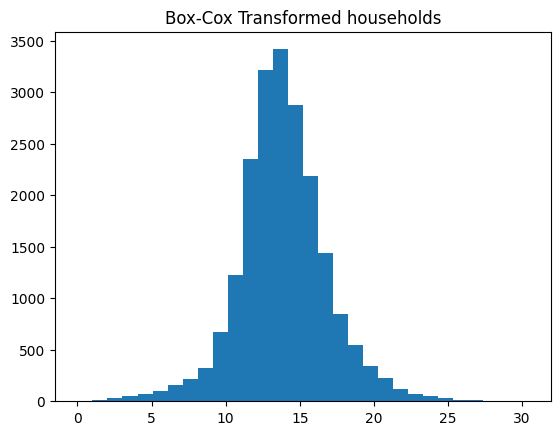

households skewness after transform: 0.11595292504111401


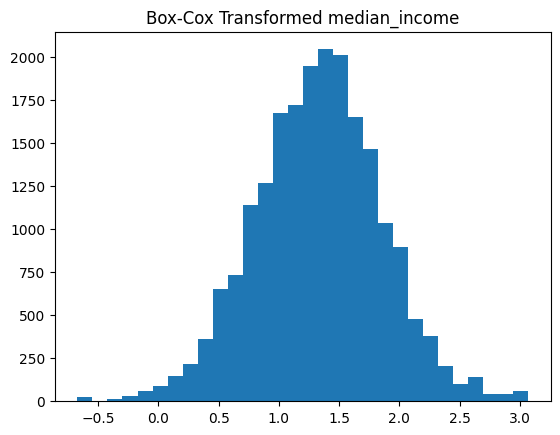

median_income skewness after transform: 0.004876246648249589


In [3]:
#q1(b)
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="box-cox", standardize=False)

for feature in features:
    transformed = pt.fit_transform(housing[[feature]])
    
    plt.figure()
    plt.hist(transformed, bins=30)
    plt.title(f"Box-Cox Transformed {feature}")
    plt.show()
    
    print(f"{feature} skewness after transform:", 
          pd.Series(transformed.flatten()).skew())

Box-Cox transformation was applied to all selected features using the PowerTransformer method with the parameter method="box-cox" and standardize=False. After transformation, histograms were plotted again and skewness values were recalculated.

The skewness values after transformation are approximately:

* total_bedrooms: 0.11
* total_rooms: 0.12
* population: 0.11
* households: 0.12
* median_income: 0.00

Compared to part (a), where skewness values were significantly higher (between ~1.6 and ~4.9), the skewness has dramatically decreased for all features. The distributions now appear much more symmetric and closer to a normal distribution.

Therefore, Box-Cox transformation successfully reduced skewness in all features. The transformed features no longer exhibit significant skewness and can be considered approximately normally distributed.

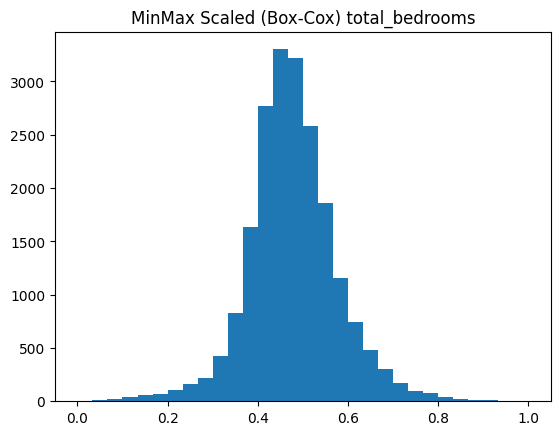

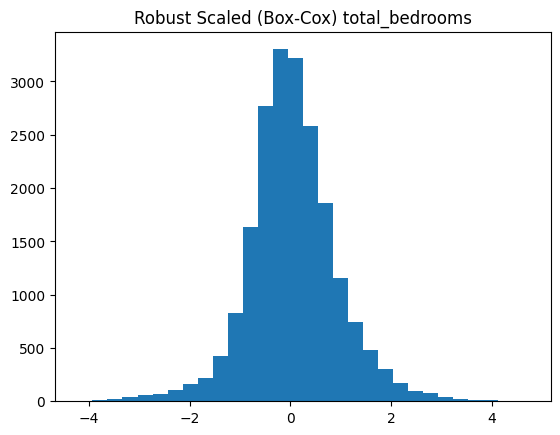

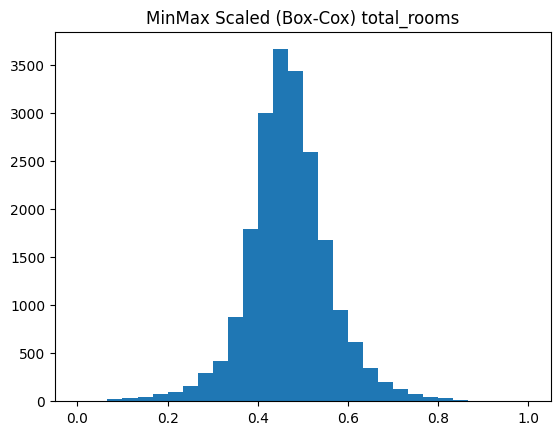

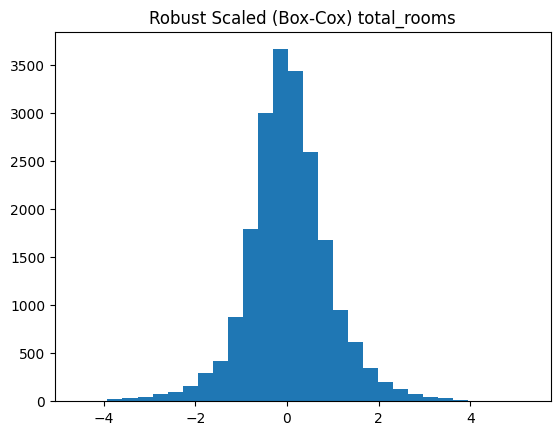

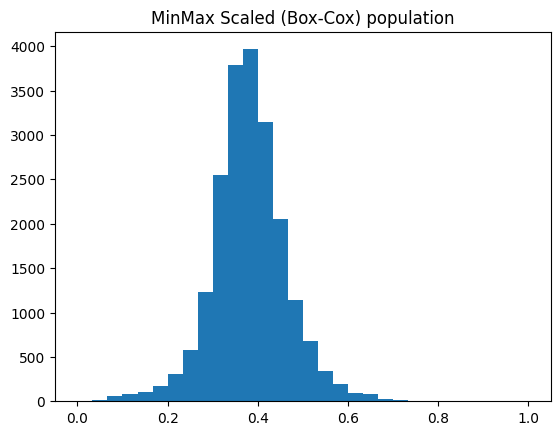

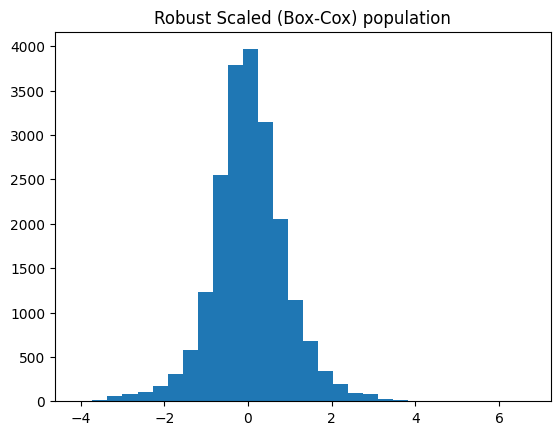

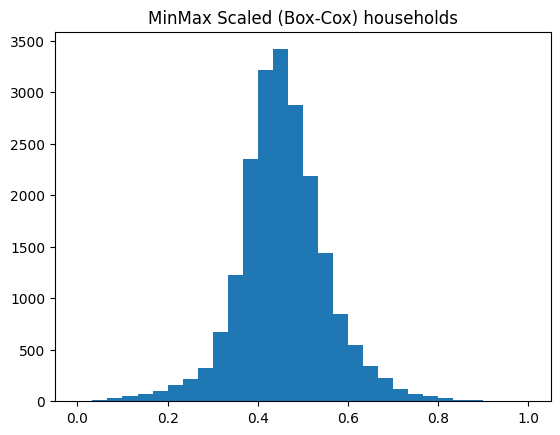

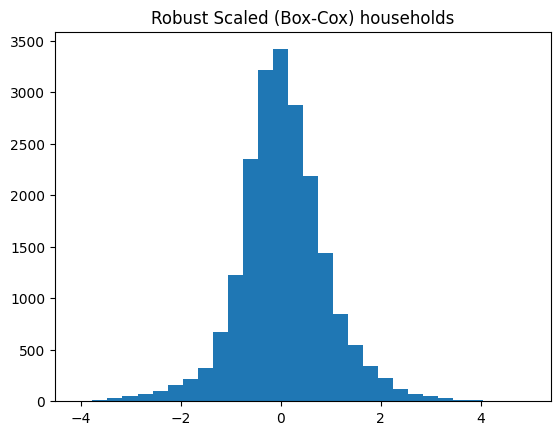

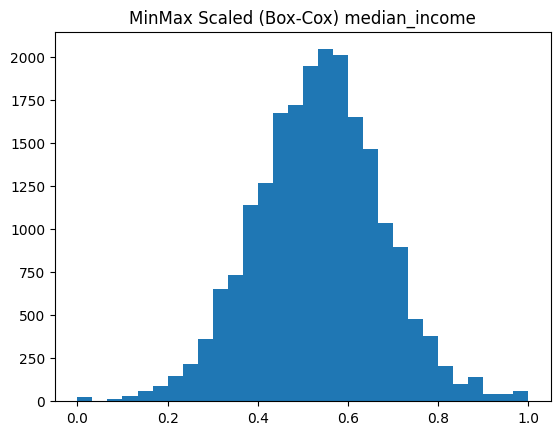

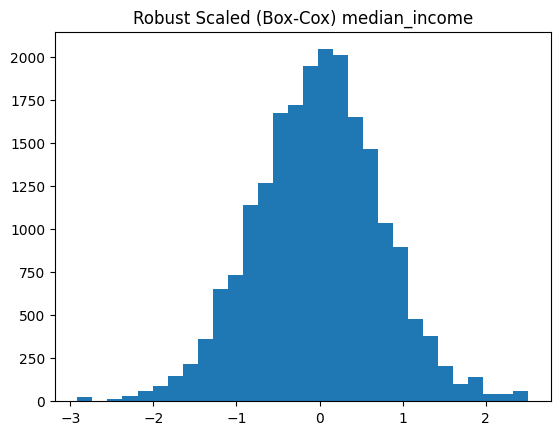

In [4]:
# Q1(c)

from sklearn.preprocessing import MinMaxScaler, RobustScaler, PowerTransformer

minmax = MinMaxScaler()
robust = RobustScaler()
pt = PowerTransformer(method="box-cox", standardize=False)

for feature in features:
    #  1. Box-Cox uygula
    transformed = pt.fit_transform(housing[[feature]])
    
    #  2. Scaling uygula
    minmax_scaled = minmax.fit_transform(transformed)
    robust_scaled = robust.fit_transform(transformed)
    
    #  3. Plot MinMax
    plt.figure()
    plt.hist(minmax_scaled, bins=30)
    plt.title(f"MinMax Scaled (Box-Cox) {feature}")
    plt.show()
    
    #  4. Plot Robust
    plt.figure()
    plt.hist(robust_scaled, bins=30)
    plt.title(f"Robust Scaled (Box-Cox) {feature}")
    plt.show()

Min-Max scaling and Robust scaling were applied to the Box-Cox transformed features obtained in part (b). After applying both scaling methods, histograms were plotted to analyze the resulting distributions.

Since the data had already been transformed using Box-Cox, the distributions were approximately symmetric before scaling. Both scaling methods preserved this overall shape and did not introduce additional skewness.

MinMaxScaler scaled the data into the range [0, 1], as observed in the histograms. While this provides a uniform scale, it remains sensitive to outliers. Even after Box-Cox transformation, extreme values still slightly influence the scaling range, causing some compression of the data near the center.

In contrast, RobustScaler scaled the data using the median and interquartile range (IQR). As a result, the distributions appear more balanced around zero, and the influence of any remaining outliers is minimized. The spread of the data is more consistent compared to MinMax scaling.

In terms of distribution shape, both methods maintain the approximately normal shape achieved after Box-Cox transformation. However, RobustScaler provides a more stable scaling by reducing the effect of outliers, whereas MinMaxScaler is still affected by extreme values.

In conclusion, although both methods preserve the distribution shape after transformation, RobustScaler is more robust to outliers, while MinMaxScaler is more sensitive and may compress the data due to extreme values.

**Q1(d)**

RobustScaler is preferred over MinMaxScaler when the dataset contains outliers or extreme values. In part (a), the features showed strong positive skewness, indicating the presence of significant outliers. Even after Box-Cox transformation in part (b), although skewness was reduced, extreme values still influenced the scaling process.

As observed in part (c), MinMaxScaler compressed most of the data into a narrow range due to the presence of outliers, causing a loss of detail in the central distribution. In contrast, RobustScaler, which is based on the median and interquartile range (IQR), was less affected by these extreme values and preserved the structure of the data more effectively.

Therefore, RobustScaler is preferred when the data contains outliers, as it provides a more reliable and stable scaling compared to MinMaxScaler.

In [5]:
#Q2(a)
with open("/kaggle/input/datasets/rtatman/character-encoding-examples/die_ISO-8859-1.txt", "rb") as f:
    raw_data = f.read()

print(raw_data[:1000])

b"The Project Gutenberg EBook of Die F\xfcrstin, by Kasimir Edschmid\r\n\r\nThis eBook is for the use of anyone anywhere at no cost and with\r\nalmost no restrictions whatsoever.  You may copy it, give it away or\r\nre-use it under the terms of the Project Gutenberg License included\r\nwith this eBook or online at www.gutenberg.net\r\n\r\n\r\nTitle: Die F\xfcrstin\r\n\r\nAuthor: Kasimir Edschmid\r\n\r\nRelease Date: May 15, 2010 [EBook #32385]\r\n\r\nLanguage: German\r\n\r\nCharacter set encoding: ISO-8859-1\r\n\r\n*** START OF THIS PROJECT GUTENBERG EBOOK DIE F\xdcRSTIN ***\r\n\r\n\r\n\r\n\r\nProduced by Jens Sadowski\r\n\r\n\r\n\r\n\r\nTranscriber's Note:\r\nDouble quotation marks have been encoded as \xbb and \xab.\r\n\r\n\r\n\r\n\r\nKASIMIR EDSCHMID\r\n\r\nDIE F\xdcRSTIN\r\n\r\n\r\n\r\n\r\n\r\n1920\r\n\r\nPAUL CASSIRER VERLAG \xb7 BERLIN\r\n\r\n\r\n\r\nALLE RECHTE VORBEHALTEN\r\n\r\nCOPYRIGHT 1920 BY PAUL CASSIRER \xb7 BERLIN\r\n\r\n\r\n\r\n\r\n\r\n\r\nGESCHRIEBEN NEUNZEHNHUNDERTSE

The file was read in binary mode using the default encoding (no encoding specified). The output shows that the content is displayed as a byte string (starting with b'...') and contains escape characters such as \n and \r.

Although the text is partially readable, it is not properly formatted as a clean string. The presence of byte notation and escape sequences indicates that the file has not been decoded into a human-readable format.

Therefore, the text appears unformatted and not fully readable, and proper decoding is required to correctly interpret the content.

In [6]:
#Q2(b)
import chardet

result = chardet.detect(raw_data[:100000])
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.6794623462562037, 'language': ''}


In [7]:
#Q2(c)
decoded_data = raw_data.decode("ISO-8859-1")

print(decoded_data[:1000])

The Project Gutenberg EBook of Die Fürstin, by Kasimir Edschmid

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.net


Title: Die Fürstin

Author: Kasimir Edschmid

Release Date: May 15, 2010 [EBook #32385]

Language: German

Character set encoding: ISO-8859-1

*** START OF THIS PROJECT GUTENBERG EBOOK DIE FÜRSTIN ***




Produced by Jens Sadowski




Transcriber's Note:
Double quotation marks have been encoded as » and «.




KASIMIR EDSCHMID

DIE FÜRSTIN





1920

PAUL CASSIRER VERLAG · BERLIN



ALLE RECHTE VORBEHALTEN

COPYRIGHT 1920 BY PAUL CASSIRER · BERLIN






GESCHRIEBEN NEUNZEHNHUNDERTSECHZEHN




INHALT

DAS FRAUENSCHLOSS
JAEL
DIE ABENTEUERLICHE NACHT
BRIEF
TRAUM









DAS FRAUENSCHLOSS


DIE Drac


The file was decoded using the correct encoding method (ISO-8859-1). After applying the decode operation, the output is no longer in byte format and is displayed as a properly formatted string.

Unlike part (a), the text is now clearly readable, and special characters are correctly interpreted. The escape sequences (such as \n and \r) are now rendered as proper line breaks, making the structure of the text understandable.

Therefore, the text is now in the correct format, and decoding has successfully resolved the formatting issue observed in part (a).

In [8]:
#Q2(d)
with open("die_ISO-8859-1_utf-8.txt", "w", encoding="utf-8") as f:
    f.write(decoded_data)

In [9]:
#Q3(a)
food = pd.read_csv("/kaggle/input/datasets/shrutisaxena/food-nutrition-dataset/food.csv")
categories = food["Category"].dropna().unique()
categories_sorted = sorted(categories)

print(categories_sorted[:100])
print("Total unique:", len(categories_sorted))

['ABALONE', 'ABIYUCH', 'ACEROLA', 'ACEROLA JUICE', 'ACORN FLOUR', 'ACORNS', 'AGAVE', 'AGUTUK', 'ALCOHOLIC BEV', 'ALFALFA SEEDS', 'ALLSPICE', 'ALMOND BUTTER', 'ALMONDS', 'AMARANTH', 'AMARANTH GRAIN', 'AMARANTH LEAVES', 'ANCHOVY', 'ANIMAL FAT', 'APPLE CIDER-FLAVORED DRK', 'APPLE JUC', 'APPLES', 'APPLESAUCE', 'APRICOT NECTAR', 'APRICOTS', 'ARCHWAY HOME STYLE COOKIES', 'ARCHWAY Home Style Cookies', 'ARROWHEAD', 'ARROWROOT', 'ARTICHOKES', 'ARTIFICIAL BLUEBERRY MUFFIN MIX', 'ARUGULA', 'ASPARAGUS', 'AVOCADOS', 'BABYFOOD', 'BACON', 'BACON BITS', 'BAGEL', 'BAGELS', 'BAKED BNS', 'BAKING CHOC', 'BALSAM-PEAR (BITTER GOURD)', 'BAMBOO SHOOTS', 'BANANAS', 'BANQUET CHICK POT PIE', 'BANQUET GRY & SALURY STK W/ MSHD POT & CORN IN SEASONSAU', 'BANQUET HEARTY ONE STK DIN', 'BANQUET ORIG FRIED CHK THIGH', 'BANQUET SLCED BF W/GRY', 'BANQUET TKY & GRY W/DRESS ', 'BARBECUE LOAF', 'BARLEY', 'BASIL', 'BASS', 'BEANS', 'BEAR', 'BEECHNUTS', 'BEEF', 'BEEF BROTH&TOMATO JUC', 'BEEF JERKY', 'BEEF POT PIE', 'BEEF SAUSA

The Food Nutrition dataset was loaded, and the categorical column “Category” was selected. The unique values in this column were extracted, sorted alphabetically, and the first 100 values were printed.

The total number of unique food categories is 1183, indicating a high level of variability in the dataset.

Upon inspection of the category names, several potential inconsistencies were identified. For example:

* “ALMOND” vs “ALMONDS” (singular vs plural form)
* “ACEROLA” vs “ACEROLA JUICE” (same base ingredient but different representation)

These inconsistencies may arise due to differences in naming conventions, pluralization, or additional descriptive words. Such variations can lead to redundancy and should be handled during data cleaning.

In [10]:
#Q3(b)
food["Category"] = food["Category"].str.lower().str.strip()

categories_clean = sorted(food["Category"].dropna().unique())
print(categories_clean[:100])
print("Unique count after cleaning:", len(categories_clean))
print("First:", categories_clean[0])
print("100th:", categories_clean[99])

['abalone', 'abiyuch', 'acerola', 'acerola juice', 'acorn flour', 'acorns', 'agave', 'agutuk', 'alcoholic bev', 'alfalfa seeds', 'allspice', 'almond butter', 'almonds', 'amaranth', 'amaranth grain', 'amaranth leaves', 'anchovy', 'animal fat', 'apple cider-flavored drk', 'apple juc', 'apples', 'applesauce', 'apricot nectar', 'apricots', 'archway home style cookies', 'arrowhead', 'arrowroot', 'artichokes', 'artificial blueberry muffin mix', 'arugula', 'asparagus', 'avocados', 'babyfood', 'bacon', 'bacon bits', 'bagel', 'bagels', 'baked bns', 'baking choc', 'balsam-pear (bitter gourd)', 'bamboo shoots', 'bananas', 'banquet chick pot pie', 'banquet gry & salury stk w/ mshd pot & corn in seasonsau', 'banquet hearty one stk din', 'banquet orig fried chk thigh', 'banquet slced bf w/gry', 'banquet tky & gry w/dress', 'barbecue loaf', 'barley', 'basil', 'bass', 'beans', 'bear', 'beechnuts', 'beef', 'beef broth&tomato juc', 'beef jerky', 'beef pot pie', 'beef sausage', 'beef stew', 'beerwurst', 

Basic text cleaning techniques were applied by converting all entries in the “Category” column to lowercase and removing leading and trailing whitespace. After cleaning, the number of unique food categories became 1165.

Compared to the original number of unique categories (1183), the number has decreased, indicating that some inconsistencies such as differences in capitalization and extra spaces were successfully resolved. As a result, duplicate entries that previously appeared as separate categories were merged.

After cleaning, the unique category values were sorted alphabetically, and the first 100 values were printed. The first value in the sorted list is "abalone", and the 100th value is "brotwurst".

Overall, the cleaning process improved the consistency of the dataset by reducing redundant category entries.

In [11]:
#Q3(c)
from fuzzywuzzy import process, fuzz

matches = process.extract(
    "beet greens", 
    food["Category"].unique(), 
    limit=10, 
    scorer=fuzz.token_sort_ratio
)

print(matches)

high_matches = [m for m in matches if m[1] >= 90]
print("Matches with score >= 90:", high_matches)

[('beet greens', 100), ('beet grns', 90), ('entrees', 67), ('green giant', 64), ('beets', 62), ('dandelion greens', 59), ('sweeteners', 57), ('chicory greens', 56), ('george weston bakeries', 55), ('the budget gourmet', 55)]
Matches with score >= 90: [('beet greens', 100), ('beet grns', 90)]


/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Fuzzy matching was applied using the fuzzywuzzy library to identify category names similar to “beet greens”. The process.extract method was used with a limit of 10 and the token_sort_ratio scoring function.

The closest matches and their similarity scores were obtained. Among these results, the following entries have similarity scores greater than or equal to 90:

* “beet greens” → 100
* “beet grns” → 90

These results indicate that “beet grns” is likely an abbreviated or misspelled version of “beet greens”, and both entries represent the same category.

The closest match to “beet greens” is itself with a score of 100. The next closest match is “beet grns” with a score of 90.

Other matches such as “beets” or “dandelion greens” have lower similarity scores and are less likely to represent the exact same category.

In [12]:
# Q3(d)

from fuzzywuzzy import process

def replace_matches_in_column(df, column, string_to_match, min_ratio=85):
    strings = df[column].unique()
    
    matches = process.extract(string_to_match, strings, limit=10)
    
    close_matches = [match[0] for match in matches if match[1] >= min_ratio]
    
    rows_with_matches = df[column].isin(close_matches)
    
    df.loc[rows_with_matches, column] = string_to_match
    
    return df

# apply function
food = replace_matches_in_column(food, "Category", "beet greens", min_ratio=85)

#  UNIQUE SAYI
categories = sorted(food["Category"].unique())

print("Total unique after cleaning:", len(categories))

#  İLK 100
print(categories[:100])

#  KONTROL (en kritik)
print("\nCheck 'beet greens' entries:")
print([cat for cat in categories if "beet" in cat])

Total unique after cleaning: 1164
['abalone', 'abiyuch', 'acerola', 'acerola juice', 'acorn flour', 'acorns', 'agave', 'agutuk', 'alcoholic bev', 'alfalfa seeds', 'allspice', 'almond butter', 'almonds', 'amaranth', 'amaranth grain', 'amaranth leaves', 'anchovy', 'animal fat', 'apple cider-flavored drk', 'apple juc', 'apples', 'applesauce', 'apricot nectar', 'apricots', 'archway home style cookies', 'arrowhead', 'arrowroot', 'artichokes', 'artificial blueberry muffin mix', 'arugula', 'asparagus', 'avocados', 'babyfood', 'bacon', 'bacon bits', 'bagel', 'bagels', 'baked bns', 'baking choc', 'balsam-pear (bitter gourd)', 'bamboo shoots', 'bananas', 'banquet chick pot pie', 'banquet gry & salury stk w/ mshd pot & corn in seasonsau', 'banquet hearty one stk din', 'banquet orig fried chk thigh', 'banquet slced bf w/gry', 'banquet tky & gry w/dress', 'barbecue loaf', 'barley', 'basil', 'bass', 'beans', 'bear', 'beechnuts', 'beef', 'beef broth&tomato juc', 'beef jerky', 'beef pot pie', 'beef sa

A fuzzy matching approach was used to standardize inconsistent entries related to “beet greens”. The replace_matches_in_column function was applied with a minimum similarity ratio of 85 to group similar category names under the single label “beet greens”.

After applying the replacements, the number of unique food categories decreased from 1165 to 1164, indicating that at least one inconsistent entry (such as “beet grns”) was successfully merged into “beet greens”.

The sorted list of unique categories was generated again, and the first 100 values were printed. It was verified that “beet greens” now appears as a standardized category.

However, the check shows that “beets” still exists as a separate category. This suggests that while fuzzy matching successfully merged very similar entries (e.g., abbreviations), some related but semantically different categories (like singular/plural or related food items) may remain distinct.

Overall, the cleaning process improved consistency by reducing duplicate or inconsistent representations of “beet greens”, although some related variations may still require further manual or semantic cleaning.